# Benchmark Analysis

This notebook analyzes the redefined benchmark bundled under results/benchmark/campaigns.


## 1. Imports


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError(f'Could not locate repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
BENCHMARK_ROOT = REPO_ROOT / 'results' / 'benchmark'
CAMPAIGNS_ROOT = BENCHMARK_ROOT / 'campaigns'
RUNTIME_CSV_PATH = BENCHMARK_ROOT / 'tables' / 'benchmark_runtime_recovered.csv'

METHOD_ORDER = ['lhs_static', 'qbc_deep_ensemble', 'marker_directed', 'qbc_marker_hybrid']
ADAPTIVE_METHODS = [m for m in METHOD_ORDER if m != 'lhs_static']
BUDGET_ORDER = ['b1024', 'b4096', 'b8192']
MODEL_ORDER = ['SM4', 'SM6', 'SM9']

METHOD_LABELS = {
    'lhs_static': 'LHS Static',
    'qbc_deep_ensemble': 'QBC Deep Ensemble',
    'marker_directed': 'Marker Directed',
    'qbc_marker_hybrid': 'QBC Marker Hybrid',
}

CAMPAIGN_LABELS = {
    'benchmark_sm4': 'SM4',
    'benchmark_sm6': 'SM6',
    'benchmark_sm_avr_gov': 'SM9',
}

METHOD_COLORS = {
    'qbc_deep_ensemble': '#1f77b4',
    'marker_directed': '#2ca02c',
    'qbc_marker_hybrid': '#d62728',
}

print('REPO_ROOT:', REPO_ROOT)
print('CAMPAIGNS_ROOT:', CAMPAIGNS_ROOT)


REPO_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems
CAMPAIGNS_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/results/benchmark/campaigns


## 2. Read In The Data


In [2]:
def load_campaign_bundle(campaigns_root: Path) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, dict]]:
    metric_frames = []
    manifest_rows = []
    campaign_meta_lookup: dict[str, dict] = {}

    for campaign_dir in sorted(campaigns_root.glob('benchmark_*')):
        manifest_path = campaign_dir / 'campaign_manifest.json'
        metrics_path = campaign_dir / 'dataset_benchmark_metrics.csv'
        if not manifest_path.exists() or not metrics_path.exists():
            continue

        manifest = json.loads(manifest_path.read_text())
        campaign = manifest.get('campaign', {})
        campaign_name = str(campaign.get('name', campaign_dir.name))
        campaign_label = CAMPAIGN_LABELS.get(campaign_name, campaign_name)
        campaign_meta_lookup[campaign_label] = {
            'campaign_dir': campaign_dir.name,
            'campaign_name': campaign_name,
            'campaign_label': campaign_label,
            'experiment_id': campaign.get('experiment_id', ''),
            'preset': campaign.get('preset', ''),
            'model_flag': campaign.get('model_flag', ''),
            'baseline_seeds': list(campaign.get('baseline_seeds', [])),
            'axes': dict(campaign.get('axes', {})),
        }

        metrics_df = pd.read_csv(metrics_path)
        metrics_df['campaign_dir'] = campaign_dir.name
        metrics_df['campaign_name'] = campaign_name
        metrics_df['campaign_label'] = campaign_label
        metrics_df['experiment_id'] = str(campaign.get('experiment_id', ''))
        metrics_df['preset'] = str(campaign.get('preset', ''))
        metric_frames.append(metrics_df)

        for run in manifest.get('dataset_runs', []):
            row = {
                'campaign_dir': campaign_dir.name,
                'campaign_name': campaign_name,
                'campaign_label': campaign_label,
                'experiment_id': str(campaign.get('experiment_id', '')),
                'preset': str(campaign.get('preset', '')),
                'method': run.get('method'),
                'budget': run.get('budget'),
                'dataset_seed': run.get('dataset_seed'),
                'status': run.get('status'),
                'duration_seconds': run.get('duration_seconds'),
                'n_baseline_seeds': len(run.get('baseline_seeds', [])),
                'started_at_utc': run.get('started_at_utc'),
                'completed_at_utc': run.get('completed_at_utc'),
            }
            manifest_rows.append(row)

    if not metric_frames:
        raise FileNotFoundError(f'No benchmark bundle found under {campaigns_root}')

    benchmark_df = pd.concat(metric_frames, ignore_index=True)
    benchmark_df['method'] = pd.Categorical(benchmark_df['method'], categories=METHOD_ORDER, ordered=True)
    benchmark_df['budget'] = pd.Categorical(benchmark_df['budget'], categories=BUDGET_ORDER, ordered=True)
    benchmark_df['method_label'] = benchmark_df['method'].astype(str).map(METHOD_LABELS)

    manifest_runs_df = pd.DataFrame(manifest_rows)
    if not manifest_runs_df.empty:
        manifest_runs_df['budget'] = pd.Categorical(manifest_runs_df['budget'], categories=BUDGET_ORDER, ordered=True)

    return benchmark_df, manifest_runs_df, campaign_meta_lookup


benchmark_df, manifest_runs_df, campaign_meta_lookup = load_campaign_bundle(CAMPAIGNS_ROOT)
runtime_df = pd.read_csv(RUNTIME_CSV_PATH)
runtime_df['campaign_label'] = runtime_df['campaign_name'].map(CAMPAIGN_LABELS)
runtime_df['budget'] = pd.Categorical(runtime_df['budget'], categories=BUDGET_ORDER, ordered=True)
runtime_df['method'] = pd.Categorical(runtime_df['method'], categories=METHOD_ORDER, ordered=True)
runtime_df['method_label'] = runtime_df['method'].astype(str).map(METHOD_LABELS)
display(benchmark_df.head())
display(manifest_runs_df.head())
display(runtime_df.head())


,method,budget,dataset_seed,mse_mean,mse_std,rmse_mean,rmse_std,campaign_dir,campaign_name,campaign_label,experiment_id,preset,method_label
0,lhs_static,b1024,ds01,0.000948,0.000087,0.030766,0.001407,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,LHS Static
1,lhs_static,b1024,ds02,0.001104,0.000056,0.033226,0.000847,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,LHS Static
2,lhs_static,b1024,ds03,0.001140,0.000107,0.033742,0.001612,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,LHS Static
3,lhs_static,b1024,ds04,0.001046,0.000287,0.032122,0.004531,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,LHS Static
4,lhs_static,b1024,ds05,0.001382,0.000260,0.037065,0.003517,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,LHS Static


,campaign_dir,campaign_name,campaign_label,experiment_id,preset,method,budget,dataset_seed,status,duration_seconds,n_baseline_seeds,started_at_utc,completed_at_utc
0,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,lhs_static,b1024,ds01,skipped_existing,NaN,3,2026-03-25T09:04:16.307754+00:00,2026-03-25T09:04:16.328870+00:00
1,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,lhs_static,b1024,ds02,skipped_existing,NaN,3,2026-03-25T09:04:16.331211+00:00,2026-03-25T09:04:16.343832+00:00
2,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,lhs_static,b1024,ds03,skipped_existing,NaN,3,2026-03-25T09:04:16.346184+00:00,2026-03-25T09:04:16.361831+00:00
3,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,lhs_static,b1024,ds04,skipped_existing,NaN,3,2026-03-25T09:04:16.364632+00:00,2026-03-25T09:04:16.382533+00:00
4,benchmark_sm4_20260325_100330,benchmark_sm4,SM4,thesis_sm4_benchmark_sm4_v2,default,lhs_static,b1024,ds05,skipped_existing,NaN,3,2026-03-25T09:04:16.385535+00:00,2026-03-25T09:04:16.402304+00:00


,campaign_dir,campaign_name,experiment_id,preset,model_flag,method,budget,dataset_seed,campaign_status,runtime_source,total_runtime_seconds,campaign_runtime_seconds,archive_runtime_seconds,archive_manifest_path,stage1_create_dataset_status,stage1_create_dataset_runtime_seconds,stage2_preprocess_status,stage2_preprocess_runtime_seconds,stage3_baseline_status,stage3_baseline_runtime_seconds,baseline_subruns_with_runtime,baseline_total_runtime_seconds,baseline_mean_runtime_seconds,baseline_min_runtime_seconds,baseline_max_runtime_seconds,campaign_label,method_label
0,benchmark_sm4_20260325_100330,benchmark_sm4,thesis_sm4_benchmark_sm4_v2,default,SM4,lhs_static,b1024,ds01,skipped_existing,archive_manifest,51.115952,NaN,51.115952,/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/results/archive/experiments_2/thesis_sm4_benchmark_sm4_v2/default/lhs_static/b1024/ds01/dataset_manifest.json,completed,7.049700,completed,15.728967,completed,28.322241,3,28.306524,9.435508,9.112849,10.066287,SM4,LHS Static
1,benchmark_sm4_20260325_100330,benchmark_sm4,thesis_sm4_benchmark_sm4_v2,default,SM4,lhs_static,b1024,ds02,skipped_existing,archive_manifest,46.409640,NaN,46.409640,/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/results/archive/experiments_2/thesis_sm4_benchmark_sm4_v2/default/lhs_static/b1024/ds02/dataset_manifest.json,completed,7.019753,completed,11.775854,completed,27.597209,3,27.581105,9.193702,9.132986,9.297386,SM4,LHS Static
2,benchmark_sm4_20260325_100330,benchmark_sm4,thesis_sm4_benchmark_sm4_v2,default,SM4,lhs_static,b1024,ds03,skipped_existing,archive_manifest,45.906408,NaN,45.906408,/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/results/archive/experiments_2/thesis_sm4_benchmark_sm4_v2/default/lhs_static/b1024/ds03/dataset_manifest.json,completed,6.987385,completed,11.695534,completed,27.206683,3,27.190893,9.063631,9.040587,9.077195,SM4,LHS Static
3,benchmark_sm4_20260325_100330,benchmark_sm4,thesis_sm4_benchmark_sm4_v2,default,SM4,lhs_static,b1024,ds04,skipped_existing,archive_manifest,45.760188,NaN,45.760188,/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/results/archive/experiments_2/thesis_sm4_benchmark_sm4_v2/default/lhs_static/b1024/ds04/dataset_manifest.json,completed,6.962459,completed,11.661868,completed,27.119063,3,27.102549,9.034183,8.956447,9.077143,SM4,LHS Static
4,benchmark_sm4_20260325_100330,benchmark_sm4,thesis_sm4_benchmark_sm4_v2,default,SM4,lhs_static,b1024,ds05,skipped_existing,archive_manifest,46.244789,NaN,46.244789,/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/results/archive/experiments_2/thesis_sm4_benchmark_sm4_v2/default/lhs_static/b1024/ds05/dataset_manifest.json,completed,6.950413,completed,11.660543,completed,27.616750,3,27.600762,9.200254,9.062623,9.465742,SM4,LHS Static


## 3. Benchmark Structure


In [3]:
structure_rows = []
for model_label in MODEL_ORDER:
    sub = benchmark_df[benchmark_df['campaign_label'] == model_label].copy()
    run_sub = manifest_runs_df[manifest_runs_df['campaign_label'] == model_label].copy()
    meta = campaign_meta_lookup.get(model_label, {})

    duration_values = pd.to_numeric(run_sub['duration_seconds'], errors='coerce').dropna() if not run_sub.empty else pd.Series(dtype=float)
    structure_rows.append(
        {
            'model': model_label,
            'campaign_dir': meta.get('campaign_dir', ''),
            'experiment_id': meta.get('experiment_id', ''),
            'methods_total': sub['method'].nunique(),
            'adaptive_methods_total': sub[sub['method'].astype(str).isin(ADAPTIVE_METHODS)]['method'].nunique(),
            'budgets_total': sub['budget'].nunique(),
            'dataset_seeds_total': sub['dataset_seed'].nunique(),
            'baseline_seeds_per_dataset_run': len(meta.get('baseline_seeds', [])),
            'rows_in_metrics_csv': len(sub),
            'dataset_runs_total': len(run_sub),
            'baseline_runs_total': len(run_sub) * len(meta.get('baseline_seeds', [])),
            'completed_dataset_runs': int((run_sub['status'] == 'completed').sum()) if not run_sub.empty else 0,
            'reused_dataset_runs': int((run_sub['status'] == 'skipped_existing').sum()) if not run_sub.empty else 0,
            'mean_dataset_runtime_min': duration_values.mean() / 60.0 if len(duration_values) else np.nan,
            'min_dataset_runtime_min': duration_values.min() / 60.0 if len(duration_values) else np.nan,
            'max_dataset_runtime_min': duration_values.max() / 60.0 if len(duration_values) else np.nan,
        }
    )

benchmark_structure_df = pd.DataFrame(structure_rows)
display(benchmark_structure_df)

run_grid_df = (
    benchmark_df.groupby(['campaign_label', 'budget', 'method'], observed=True)['dataset_seed']
    .nunique()
    .rename('dataset_seeds_per_method_budget')
    .reset_index()
)
display(run_grid_df)


,model,campaign_dir,experiment_id,methods_total,adaptive_methods_total,budgets_total,dataset_seeds_total,baseline_seeds_per_dataset_run,rows_in_metrics_csv,dataset_runs_total,baseline_runs_total,completed_dataset_runs,reused_dataset_runs,mean_dataset_runtime_min,min_dataset_runtime_min,max_dataset_runtime_min
0,SM4,benchmark_sm4_20260325_100330,thesis_sm4_benchmark_sm4_v2,4,3,3,5,3,60,60,180,48,12,25.865407,1.960660,73.959121
1,SM6,benchmark_sm6_20260325_110308,thesis_sm6_benchmark_sm6_v1,4,3,3,5,3,60,60,180,35,25,28.852440,2.479605,69.946689
2,SM9,benchmark_sm_avr_gov_20260326_070307,thesis_sm_avr_gov_benchmark_v1,4,3,3,5,3,60,60,180,50,10,32.373492,2.851572,93.019330


,campaign_label,budget,method,dataset_seeds_per_method_budget
0,SM4,b1024,lhs_static,5
1,SM4,b1024,qbc_deep_ensemble,5
2,SM4,b1024,marker_directed,5
3,SM4,b1024,qbc_marker_hybrid,5
4,SM4,b4096,lhs_static,5
5,SM4,b4096,qbc_deep_ensemble,5
6,SM4,b4096,marker_directed,5
7,SM4,b4096,qbc_marker_hybrid,5
8,SM4,b8192,lhs_static,5
9,SM4,b8192,qbc_deep_ensemble,5


## Relative Comparison Against The LHS Baseline

All adaptive-method summaries below are computed on matched `campaign × budget × dataset_seed` pairs relative to `lhs_static`.


In [4]:
baseline_df = (
    benchmark_df[benchmark_df['method'].astype(str) == 'lhs_static']
    [['campaign_label', 'budget', 'dataset_seed', 'mse_mean', 'rmse_mean', 'rmse_std']]
    .rename(columns={
        'mse_mean': 'lhs_mse_mean',
        'rmse_mean': 'lhs_rmse_mean',
        'rmse_std': 'lhs_rmse_std',
    })
)

adaptive_df = benchmark_df[benchmark_df['method'].astype(str).isin(ADAPTIVE_METHODS)].copy()
paired_df = adaptive_df.merge(
    baseline_df,
    on=['campaign_label', 'budget', 'dataset_seed'],
    how='left',
    validate='many_to_one',
)

paired_df['rmse_delta'] = paired_df['lhs_rmse_mean'] - paired_df['rmse_mean']
paired_df['mse_delta'] = paired_df['lhs_mse_mean'] - paired_df['mse_mean']
paired_df['rmse_improvement_pct'] = 100.0 * paired_df['rmse_delta'] / paired_df['lhs_rmse_mean']
paired_df['mse_improvement_pct'] = 100.0 * paired_df['mse_delta'] / paired_df['lhs_mse_mean']

relative_summary = (
    paired_df.groupby(['campaign_label', 'budget', 'method'], observed=True)
    .agg(
        n_dataset_seeds=('dataset_seed', 'nunique'),
        lhs_rmse_mean=('lhs_rmse_mean', 'mean'),
        adaptive_rmse_mean=('rmse_mean', 'mean'),
        rmse_improvement_pct_mean=('rmse_improvement_pct', 'mean'),
        rmse_improvement_pct_std=('rmse_improvement_pct', 'std'),
        rmse_improvement_pct_median=('rmse_improvement_pct', 'median'),
        rmse_improvement_pct_min=('rmse_improvement_pct', 'min'),
        rmse_improvement_pct_max=('rmse_improvement_pct', 'max'),
        mse_improvement_pct_mean=('mse_improvement_pct', 'mean'),
        win_rate_vs_lhs=('rmse_delta', lambda s: float((s > 0).mean())),
    )
    .reset_index()
)
relative_summary['method_label'] = relative_summary['method'].map(METHOD_LABELS)
relative_summary['rmse_improvement_pct_se'] = relative_summary['rmse_improvement_pct_std'] / np.sqrt(relative_summary['n_dataset_seeds'])
relative_summary['rmse_improvement_pct_ci95'] = 1.96 * relative_summary['rmse_improvement_pct_se']
display(relative_summary)


,campaign_label,budget,method,n_dataset_seeds,lhs_rmse_mean,adaptive_rmse_mean,rmse_improvement_pct_mean,rmse_improvement_pct_std,rmse_improvement_pct_median,rmse_improvement_pct_min,rmse_improvement_pct_max,mse_improvement_pct_mean,win_rate_vs_lhs,method_label,rmse_improvement_pct_se,rmse_improvement_pct_ci95
0,SM4,b1024,qbc_deep_ensemble,5,0.033384,0.024580,25.931041,8.902755,21.746096,17.684207,39.531243,43.222165,1.000000,QBC Deep Ensemble,3.981433,7.803609
1,SM4,b1024,marker_directed,5,0.033384,0.040569,-21.815209,7.350639,-21.181776,-32.484843,-11.849952,-48.713093,0.000000,Marker Directed,3.287306,6.443119
2,SM4,b1024,qbc_marker_hybrid,5,0.033384,0.027048,18.662091,6.815361,20.887279,9.579263,26.577075,32.364438,1.000000,QBC Marker Hybrid,3.047922,5.973927
3,SM4,b4096,qbc_deep_ensemble,5,0.015668,0.013627,12.340162,11.681029,15.150451,-5.771786,24.576102,21.959311,0.800000,QBC Deep Ensemble,5.223915,10.238873
4,SM4,b4096,marker_directed,5,0.015668,0.015794,-2.571278,17.340188,-11.442335,-19.883275,19.888677,-7.873666,0.400000,Marker Directed,7.754768,15.199345
5,SM4,b4096,qbc_marker_hybrid,5,0.015668,0.016437,-6.816129,18.831749,-6.723069,-29.942331,20.799409,-20.681606,0.200000,QBC Marker Hybrid,8.421814,16.506756
6,SM4,b8192,qbc_deep_ensemble,5,0.012752,0.012219,2.463193,15.924715,0.695836,-13.825663,22.540163,-1.415878,0.600000,QBC Deep Ensemble,7.121749,13.958628
7,SM4,b8192,marker_directed,5,0.012752,0.012863,-2.645851,16.210841,-6.010393,-16.045795,25.049871,-9.220088,0.200000,Marker Directed,7.249708,14.209428
8,SM4,b8192,qbc_marker_hybrid,5,0.012752,0.012532,-0.764278,23.702420,-8.034367,-25.027641,30.949928,-7.758109,0.400000,QBC Marker Hybrid,10.600044,20.776087
9,SM6,b1024,qbc_deep_ensemble,5,0.028436,0.023835,15.579787,15.032114,17.966920,-2.187902,35.180450,26.309662,0.800000,QBC Deep Ensemble,6.722566,13.176229


## 4. Benchmark Summary Tables Per Model


In [5]:
summary_columns = [
    'budget',
    'method_label',
    'n_dataset_seeds',
    'lhs_rmse_mean',
    'adaptive_rmse_mean',
    'rmse_improvement_pct_mean',
    'rmse_improvement_pct_median',
    'rmse_improvement_pct_min',
    'rmse_improvement_pct_max',
    'rmse_improvement_pct_ci95',
    'win_rate_vs_lhs',
]

for model_label in MODEL_ORDER:
    print(model_label)
    model_table = (
        relative_summary[relative_summary['campaign_label'] == model_label][summary_columns]
        .sort_values(['budget', 'rmse_improvement_pct_mean'], ascending=[True, False])
        .reset_index(drop=True)
    )
    display(model_table)


SM4


,budget,method_label,n_dataset_seeds,lhs_rmse_mean,adaptive_rmse_mean,rmse_improvement_pct_mean,rmse_improvement_pct_median,rmse_improvement_pct_min,rmse_improvement_pct_max,rmse_improvement_pct_ci95,win_rate_vs_lhs
0,b1024,QBC Deep Ensemble,5,0.033384,0.024580,25.931041,21.746096,17.684207,39.531243,7.803609,1.000000
1,b1024,QBC Marker Hybrid,5,0.033384,0.027048,18.662091,20.887279,9.579263,26.577075,5.973927,1.000000
2,b1024,Marker Directed,5,0.033384,0.040569,-21.815209,-21.181776,-32.484843,-11.849952,6.443119,0.000000
3,b4096,QBC Deep Ensemble,5,0.015668,0.013627,12.340162,15.150451,-5.771786,24.576102,10.238873,0.800000
4,b4096,Marker Directed,5,0.015668,0.015794,-2.571278,-11.442335,-19.883275,19.888677,15.199345,0.400000
5,b4096,QBC Marker Hybrid,5,0.015668,0.016437,-6.816129,-6.723069,-29.942331,20.799409,16.506756,0.200000
6,b8192,QBC Deep Ensemble,5,0.012752,0.012219,2.463193,0.695836,-13.825663,22.540163,13.958628,0.600000
7,b8192,QBC Marker Hybrid,5,0.012752,0.012532,-0.764278,-8.034367,-25.027641,30.949928,20.776087,0.400000
8,b8192,Marker Directed,5,0.012752,0.012863,-2.645851,-6.010393,-16.045795,25.049871,14.209428,0.200000


SM6


,budget,method_label,n_dataset_seeds,lhs_rmse_mean,adaptive_rmse_mean,rmse_improvement_pct_mean,rmse_improvement_pct_median,rmse_improvement_pct_min,rmse_improvement_pct_max,rmse_improvement_pct_ci95,win_rate_vs_lhs
0,b1024,QBC Deep Ensemble,5,0.028436,0.023835,15.579787,17.966920,-2.187902,35.180450,13.176229,0.800000
1,b1024,QBC Marker Hybrid,5,0.028436,0.025313,11.344371,9.681814,2.714124,22.872929,8.054380,1.000000
2,b1024,Marker Directed,5,0.028436,0.031604,-11.514631,-11.283348,-27.240259,4.728867,10.647823,0.200000
3,b4096,QBC Marker Hybrid,5,0.014595,0.013681,5.030068,1.303130,-11.884645,23.706438,14.585160,0.600000
4,b4096,Marker Directed,5,0.014595,0.013865,4.065269,7.735808,-17.136245,20.961723,12.212762,0.800000
5,b4096,QBC Deep Ensemble,5,0.014595,0.014798,-2.621539,-1.912880,-20.730716,18.525106,13.949987,0.400000
6,b8192,QBC Marker Hybrid,5,0.012940,0.011395,11.291236,5.772639,-0.416571,31.819799,11.051534,0.800000
7,b8192,QBC Deep Ensemble,5,0.012940,0.011559,11.083487,14.079896,-4.249458,20.107217,9.028638,0.800000
8,b8192,Marker Directed,5,0.012940,0.012831,0.514474,4.462496,-12.444521,13.151176,9.399140,0.600000


SM9


,budget,method_label,n_dataset_seeds,lhs_rmse_mean,adaptive_rmse_mean,rmse_improvement_pct_mean,rmse_improvement_pct_median,rmse_improvement_pct_min,rmse_improvement_pct_max,rmse_improvement_pct_ci95,win_rate_vs_lhs
0,b1024,QBC Deep Ensemble,5,0.097941,0.078626,19.854261,15.811720,12.759277,34.902941,8.122942,1.000000
1,b1024,Marker Directed,5,0.097941,0.080559,17.686565,19.065349,7.377001,29.520611,7.433817,1.000000
2,b1024,QBC Marker Hybrid,5,0.097941,0.082549,15.724348,13.847816,6.296663,27.343376,8.084857,1.000000
3,b4096,QBC Marker Hybrid,5,0.034529,0.031423,8.832319,7.180522,-6.022008,23.850983,9.564747,0.800000
4,b4096,Marker Directed,5,0.034529,0.033024,4.153413,3.272073,-12.320386,19.647448,11.589213,0.600000
5,b4096,QBC Deep Ensemble,5,0.034529,0.033562,2.827852,6.441753,-20.444359,17.205419,12.927064,0.600000
6,b8192,QBC Deep Ensemble,5,0.033264,0.031808,2.920824,5.043552,-25.868036,22.271774,17.252213,0.600000
7,b8192,Marker Directed,5,0.033264,0.033460,-0.992049,-1.273384,-10.936489,14.149762,8.465698,0.400000
8,b8192,QBC Marker Hybrid,5,0.033264,0.035325,-6.821056,-8.585808,-17.202063,3.704249,6.928088,0.200000


## 4a. Cross-Budget Comparison Within Each Model

This section compares budgets within a single model to answer the benchmark question of whether adaptive methods are especially beneficial at smaller data budgets.

The comparison is again expressed relative to the `lhs_static` baseline through mean RMSE improvement, spread, and win rate.


In [6]:
budget_comparison_table = (
    relative_summary[
        [
            'campaign_label', 'budget', 'method', 'method_label',
            'rmse_improvement_pct_mean', 'rmse_improvement_pct_median',
            'rmse_improvement_pct_min', 'rmse_improvement_pct_max',
            'rmse_improvement_pct_ci95', 'win_rate_vs_lhs',
        ]
    ]
    .sort_values(['campaign_label', 'method', 'budget'])
    .reset_index(drop=True)
)

for model_label in MODEL_ORDER:
    print(model_label)
    display(
        budget_comparison_table[budget_comparison_table['campaign_label'] == model_label]
        .sort_values(['method', 'budget'])
        .reset_index(drop=True)
    )


SM4


,campaign_label,budget,method,method_label,rmse_improvement_pct_mean,rmse_improvement_pct_median,rmse_improvement_pct_min,rmse_improvement_pct_max,rmse_improvement_pct_ci95,win_rate_vs_lhs
0,SM4,b1024,qbc_deep_ensemble,QBC Deep Ensemble,25.931041,21.746096,17.684207,39.531243,7.803609,1.000000
1,SM4,b4096,qbc_deep_ensemble,QBC Deep Ensemble,12.340162,15.150451,-5.771786,24.576102,10.238873,0.800000
2,SM4,b8192,qbc_deep_ensemble,QBC Deep Ensemble,2.463193,0.695836,-13.825663,22.540163,13.958628,0.600000
3,SM4,b1024,marker_directed,Marker Directed,-21.815209,-21.181776,-32.484843,-11.849952,6.443119,0.000000
4,SM4,b4096,marker_directed,Marker Directed,-2.571278,-11.442335,-19.883275,19.888677,15.199345,0.400000
5,SM4,b8192,marker_directed,Marker Directed,-2.645851,-6.010393,-16.045795,25.049871,14.209428,0.200000
6,SM4,b1024,qbc_marker_hybrid,QBC Marker Hybrid,18.662091,20.887279,9.579263,26.577075,5.973927,1.000000
7,SM4,b4096,qbc_marker_hybrid,QBC Marker Hybrid,-6.816129,-6.723069,-29.942331,20.799409,16.506756,0.200000
8,SM4,b8192,qbc_marker_hybrid,QBC Marker Hybrid,-0.764278,-8.034367,-25.027641,30.949928,20.776087,0.400000


SM6


,campaign_label,budget,method,method_label,rmse_improvement_pct_mean,rmse_improvement_pct_median,rmse_improvement_pct_min,rmse_improvement_pct_max,rmse_improvement_pct_ci95,win_rate_vs_lhs
0,SM6,b1024,qbc_deep_ensemble,QBC Deep Ensemble,15.579787,17.966920,-2.187902,35.180450,13.176229,0.800000
1,SM6,b4096,qbc_deep_ensemble,QBC Deep Ensemble,-2.621539,-1.912880,-20.730716,18.525106,13.949987,0.400000
2,SM6,b8192,qbc_deep_ensemble,QBC Deep Ensemble,11.083487,14.079896,-4.249458,20.107217,9.028638,0.800000
3,SM6,b1024,marker_directed,Marker Directed,-11.514631,-11.283348,-27.240259,4.728867,10.647823,0.200000
4,SM6,b4096,marker_directed,Marker Directed,4.065269,7.735808,-17.136245,20.961723,12.212762,0.800000
5,SM6,b8192,marker_directed,Marker Directed,0.514474,4.462496,-12.444521,13.151176,9.399140,0.600000
6,SM6,b1024,qbc_marker_hybrid,QBC Marker Hybrid,11.344371,9.681814,2.714124,22.872929,8.054380,1.000000
7,SM6,b4096,qbc_marker_hybrid,QBC Marker Hybrid,5.030068,1.303130,-11.884645,23.706438,14.585160,0.600000
8,SM6,b8192,qbc_marker_hybrid,QBC Marker Hybrid,11.291236,5.772639,-0.416571,31.819799,11.051534,0.800000


SM9


,campaign_label,budget,method,method_label,rmse_improvement_pct_mean,rmse_improvement_pct_median,rmse_improvement_pct_min,rmse_improvement_pct_max,rmse_improvement_pct_ci95,win_rate_vs_lhs
0,SM9,b1024,qbc_deep_ensemble,QBC Deep Ensemble,19.854261,15.811720,12.759277,34.902941,8.122942,1.000000
1,SM9,b4096,qbc_deep_ensemble,QBC Deep Ensemble,2.827852,6.441753,-20.444359,17.205419,12.927064,0.600000
2,SM9,b8192,qbc_deep_ensemble,QBC Deep Ensemble,2.920824,5.043552,-25.868036,22.271774,17.252213,0.600000
3,SM9,b1024,marker_directed,Marker Directed,17.686565,19.065349,7.377001,29.520611,7.433817,1.000000
4,SM9,b4096,marker_directed,Marker Directed,4.153413,3.272073,-12.320386,19.647448,11.589213,0.600000
5,SM9,b8192,marker_directed,Marker Directed,-0.992049,-1.273384,-10.936489,14.149762,8.465698,0.400000
6,SM9,b1024,qbc_marker_hybrid,QBC Marker Hybrid,15.724348,13.847816,6.296663,27.343376,8.084857,1.000000
7,SM9,b4096,qbc_marker_hybrid,QBC Marker Hybrid,8.832319,7.180522,-6.022008,23.850983,9.564747,0.800000
8,SM9,b8192,qbc_marker_hybrid,QBC Marker Hybrid,-6.821056,-8.585808,-17.202063,3.704249,6.928088,0.200000


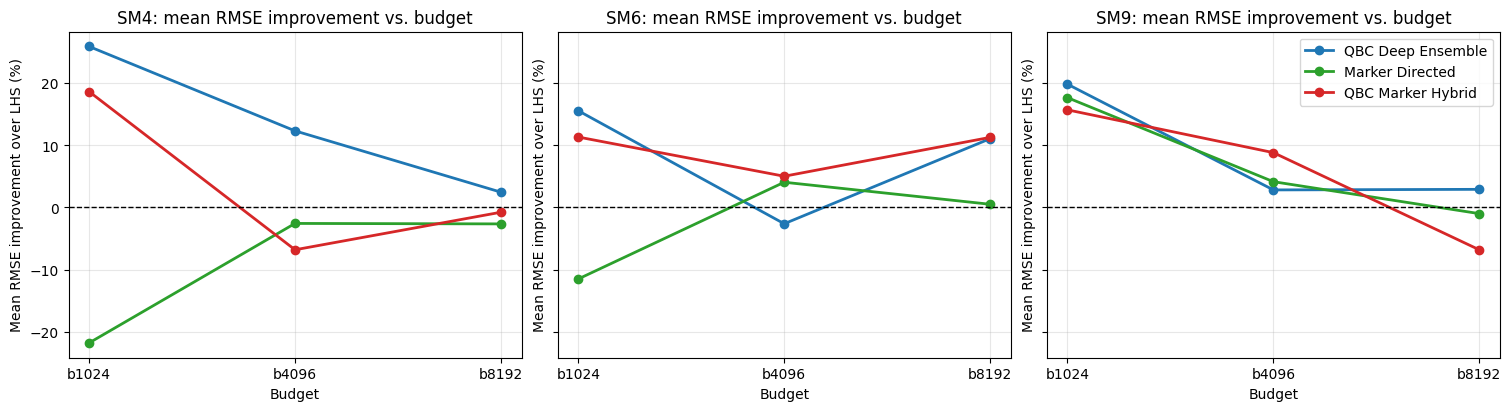

In [7]:
models_present = [m for m in MODEL_ORDER if m in relative_summary['campaign_label'].unique()]
fig, axes = plt.subplots(1, len(models_present), figsize=(15, 4), constrained_layout=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, model_label in zip(axes, models_present):
    sub = relative_summary[relative_summary['campaign_label'] == model_label].copy()
    model_budgets = [b for b in BUDGET_ORDER if b in sub['budget'].astype(str).unique()]

    for method in ADAPTIVE_METHODS:
        method_sub = sub[sub['method'].astype(str) == method].copy()
        if method_sub.empty:
            continue
        method_sub = method_sub.set_index('budget').reindex(model_budgets).reset_index()
        ax.plot(
            method_sub['budget'].astype(str),
            method_sub['rmse_improvement_pct_mean'],
            marker='o',
            linewidth=2,
            label=METHOD_LABELS[method],
            color=METHOD_COLORS[method],
        )

    ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{model_label}: mean RMSE improvement vs. budget')
    ax.set_xlabel('Budget')
    ax.set_ylabel('Mean RMSE improvement over LHS (%)')
    ax.grid(alpha=0.3)

axes[-1].legend(loc='best')
plt.show()


## 4b. Runtime Comparison Across Budgets

The recovered runtime table provides complete total runtime for all benchmark runs. Stage-level runtime is only partially available, because archived experiment manifests were recovered only for the previously skipped runs.

For that reason, the plot below compares `total_runtime_seconds` across budgets and methods. The y-axis is shown on a logarithmic scale so that both inexpensive and expensive methods remain readable in the same figure.


In [8]:
runtime_summary = (
    runtime_df.groupby(['campaign_label', 'budget', 'method'], observed=True)
    .agg(
        n_runs=('total_runtime_seconds', 'count'),
        mean_total_runtime_seconds=('total_runtime_seconds', 'mean'),
        min_total_runtime_seconds=('total_runtime_seconds', 'min'),
        max_total_runtime_seconds=('total_runtime_seconds', 'max'),
        archive_recovered_runs=('runtime_source', lambda s: int((s == 'archive_manifest').sum())),
    )
    .reset_index()
)
runtime_summary['method_label'] = runtime_summary['method'].map(METHOD_LABELS)
display(runtime_summary)


,campaign_label,budget,method,n_runs,mean_total_runtime_seconds,min_total_runtime_seconds,max_total_runtime_seconds,archive_recovered_runs,method_label
0,SM4,b1024,lhs_static,5,47.087395,45.760188,51.115952,5,LHS Static
1,SM4,b1024,qbc_deep_ensemble,5,297.853949,295.784337,299.963703,0,QBC Deep Ensemble
2,SM4,b1024,marker_directed,5,120.118304,119.093028,121.318885,0,Marker Directed
3,SM4,b1024,qbc_marker_hybrid,5,329.432347,326.768609,332.641895,0,QBC Marker Hybrid
4,SM4,b4096,lhs_static,5,80.294067,79.913016,80.693174,5,LHS Static
5,SM4,b4096,qbc_deep_ensemble,5,2116.776309,2091.769433,2141.802816,0,QBC Deep Ensemble
6,SM4,b4096,marker_directed,5,435.685188,433.844440,437.701378,0,Marker Directed
7,SM4,b4096,qbc_marker_hybrid,5,2276.291489,2248.951138,2307.239192,0,QBC Marker Hybrid
8,SM4,b8192,lhs_static,5,123.383632,117.639575,127.795388,2,LHS Static
9,SM4,b8192,qbc_deep_ensemble,5,4175.725004,4155.024304,4239.467235,0,QBC Deep Ensemble


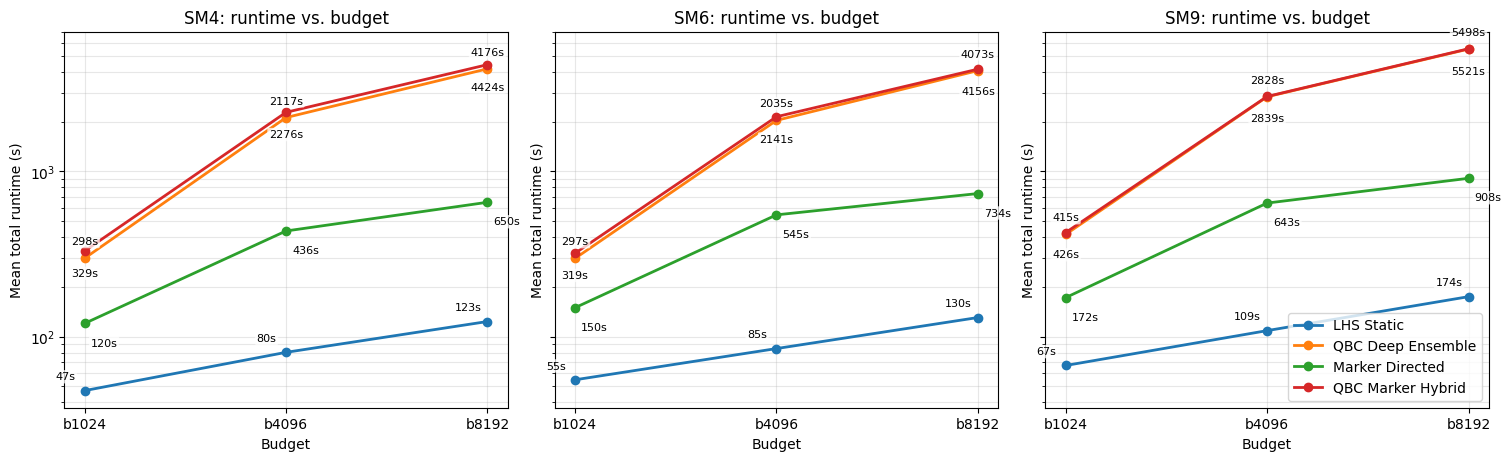

In [15]:
runtime_models_present = [m for m in MODEL_ORDER if m in runtime_summary['campaign_label'].unique()]
fig, axes = plt.subplots(1, len(runtime_models_present), figsize=(15, 4.5), constrained_layout=True, sharey=True)
axes = np.atleast_1d(axes)
annotation_offsets = {
    'lhs_static': (-14, 10),
    'qbc_deep_ensemble': (0, 12),
    'marker_directed': (14, -14),
    'qbc_marker_hybrid': (0, -16),
}

for ax, model_label in zip(axes, runtime_models_present):
    sub = runtime_summary[runtime_summary['campaign_label'] == model_label].copy()
    model_budgets = [b for b in BUDGET_ORDER if b in sub['budget'].astype(str).unique()]

    for method in METHOD_ORDER:
        method_sub = sub[sub['method'].astype(str) == method].copy()
        if method_sub.empty:
            continue
        method_sub = method_sub.set_index('budget').reindex(model_budgets).reset_index()
        x_values = method_sub['budget'].astype(str)
        y_values = method_sub['mean_total_runtime_seconds']
        ax.plot(
            x_values,
            y_values,
            marker='o',
            linewidth=2,
            label=METHOD_LABELS[method],
        )

        dx, dy = annotation_offsets.get(method, (0, 10))
        for x, y in zip(x_values, y_values):
            if pd.isna(y):
                continue
            ax.annotate(
                f'{y:.0f}s',
                xy=(x, y),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='center',
                va='center',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75),
            )

    ax.set_title(f'{model_label}: runtime vs. budget')
    ax.set_xlabel('Budget')
    ax.set_ylabel('Mean total runtime (s)')
    ax.set_yscale('log')
    ax.grid(alpha=0.3, which='both')

axes[-1].legend(loc='best')
plt.show()


## 5. Budget-Wise Bar Plots With Min-Max Indications

Each subplot shows the mean RMSE improvement over the LHS baseline for the three adaptive methods. Error bars indicate the min-max range across dataset seeds.


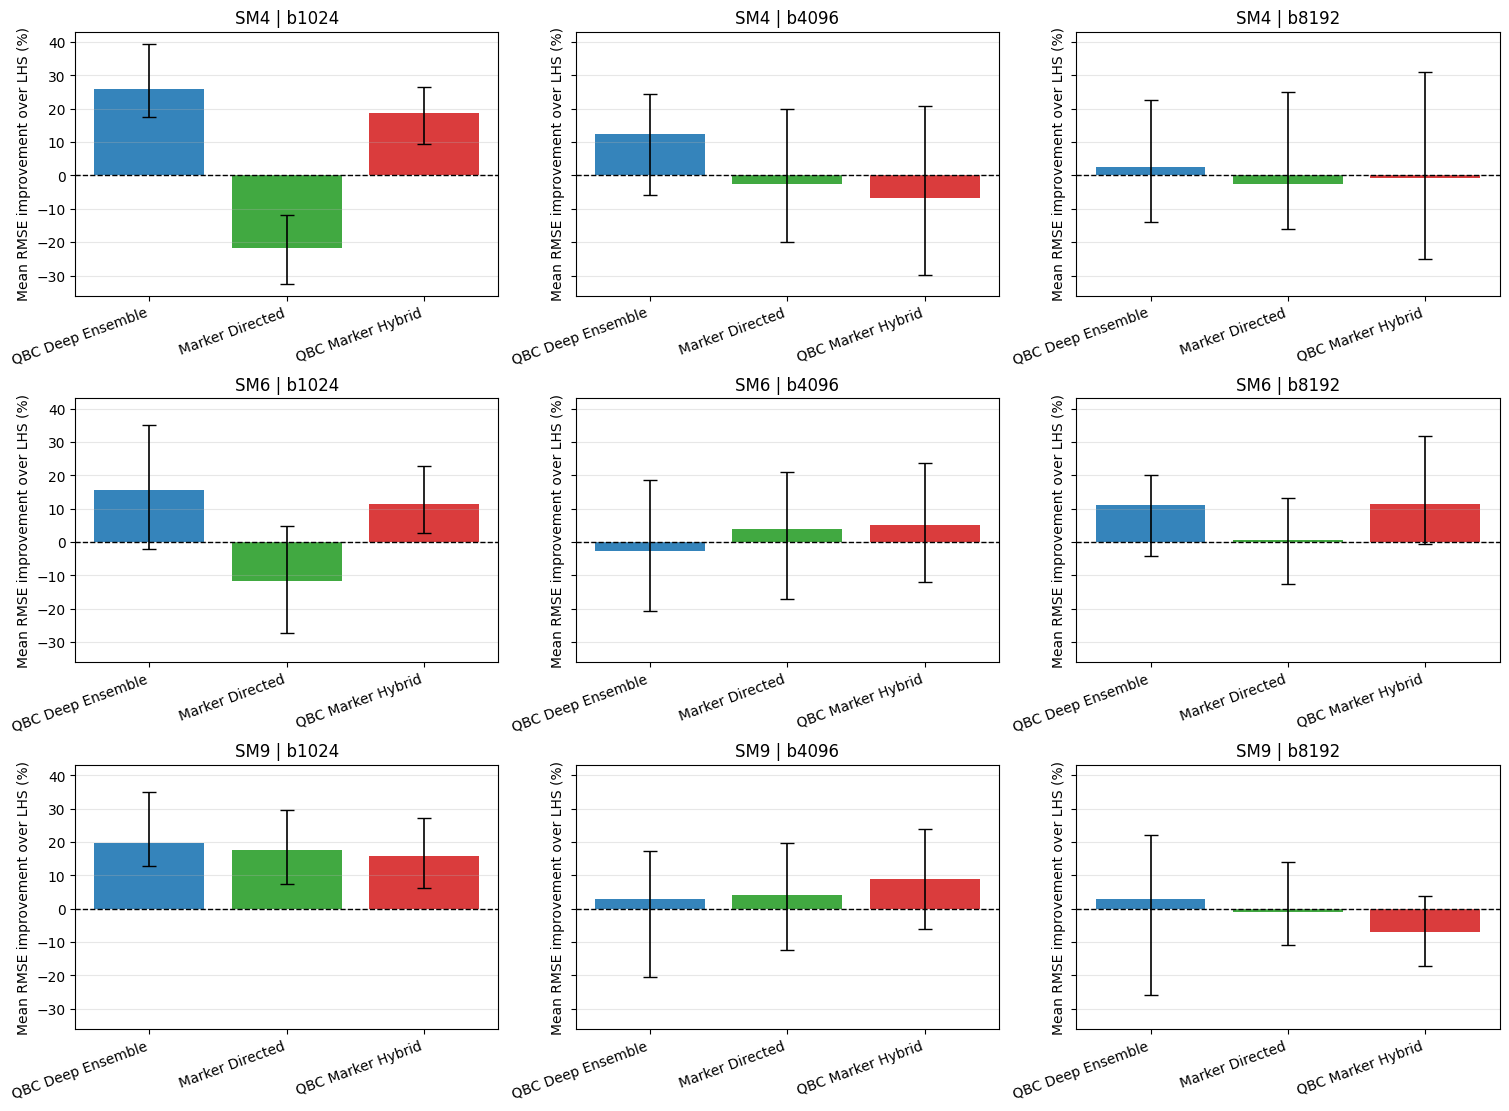

In [10]:
budgets_present = [b for b in BUDGET_ORDER if b in relative_summary['budget'].astype(str).unique()]
models_present = [m for m in MODEL_ORDER if m in relative_summary['campaign_label'].unique()]

fig, axes = plt.subplots(len(models_present), len(budgets_present), figsize=(15, 11), constrained_layout=True, sharey=True)
axes = np.atleast_2d(axes)

for i, model_label in enumerate(models_present):
    for j, budget in enumerate(budgets_present):
        ax = axes[i, j]
        sub = relative_summary[
            (relative_summary['campaign_label'] == model_label)
            & (relative_summary['budget'].astype(str) == budget)
        ].copy()
        method_order = [m for m in ADAPTIVE_METHODS if m in sub['method'].astype(str).unique()]
        sub = sub.set_index('method').loc[method_order].reset_index()

        x = np.arange(len(sub))
        heights = sub['rmse_improvement_pct_mean'].to_numpy(dtype=float)
        lower = heights - sub['rmse_improvement_pct_min'].to_numpy(dtype=float)
        upper = sub['rmse_improvement_pct_max'].to_numpy(dtype=float) - heights
        colors = [METHOD_COLORS[m] for m in sub['method'].astype(str)]

        ax.bar(x, heights, color=colors, alpha=0.9)
        ax.errorbar(x, heights, yerr=np.vstack([lower, upper]), fmt='none', ecolor='black', capsize=5, lw=1.2)
        ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
        ax.set_xticks(x, [METHOD_LABELS[m] for m in sub['method'].astype(str)], rotation=20, ha='right')
        ax.set_title(f'{model_label} | {budget}')
        ax.set_ylabel('Mean RMSE improvement over LHS (%)')
        ax.grid(axis='y', alpha=0.3)

plt.show()


## 6. Heatmap


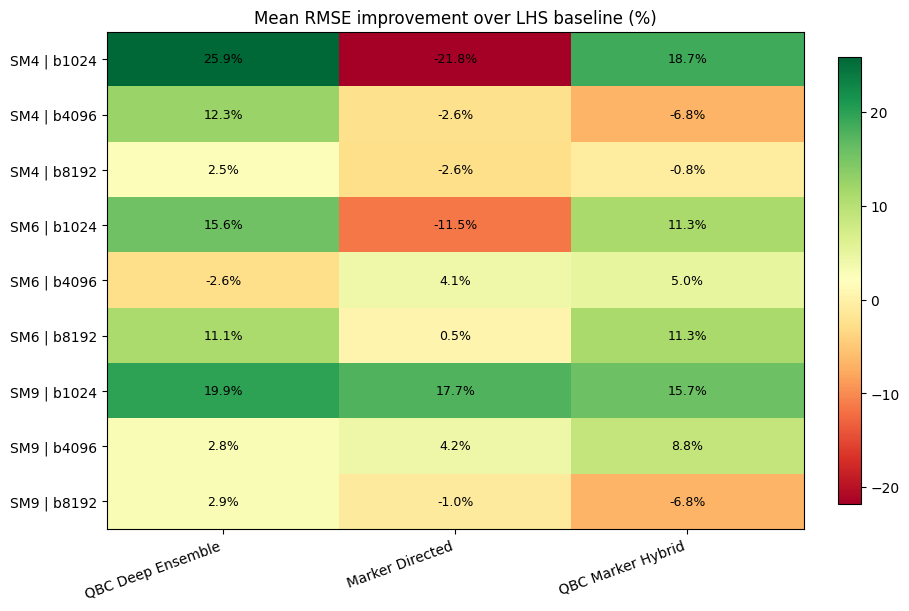

In [11]:
heatmap_df = (
    relative_summary.assign(method_label=lambda d: d['method'].map(METHOD_LABELS))
    .pivot(index=['campaign_label', 'budget'], columns='method_label', values='rmse_improvement_pct_mean')
    [[METHOD_LABELS[m] for m in ADAPTIVE_METHODS]]
)

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
im = ax.imshow(heatmap_df.to_numpy(dtype=float), cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(heatmap_df.columns)), list(heatmap_df.columns), rotation=20, ha='right')
ax.set_yticks(range(len(heatmap_df.index)), [f'{campaign} | {budget}' for campaign, budget in heatmap_df.index])
ax.set_title('Mean RMSE improvement over LHS baseline (%)')

for y in range(len(heatmap_df.index)):
    for x in range(len(heatmap_df.columns)):
        value = heatmap_df.iloc[y, x]
        ax.text(x, y, f'{value:.1f}%', ha='center', va='center', color='black', fontsize=9)

fig.colorbar(im, ax=ax, shrink=0.9)
plt.show()


## 7. Boxplots


/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_10718/1536860088.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] for m in method_order], showmeans=True)
/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_10718/1536860088.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] for m in method_order], showmeans=True)
/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_10718/1536860088.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] fo

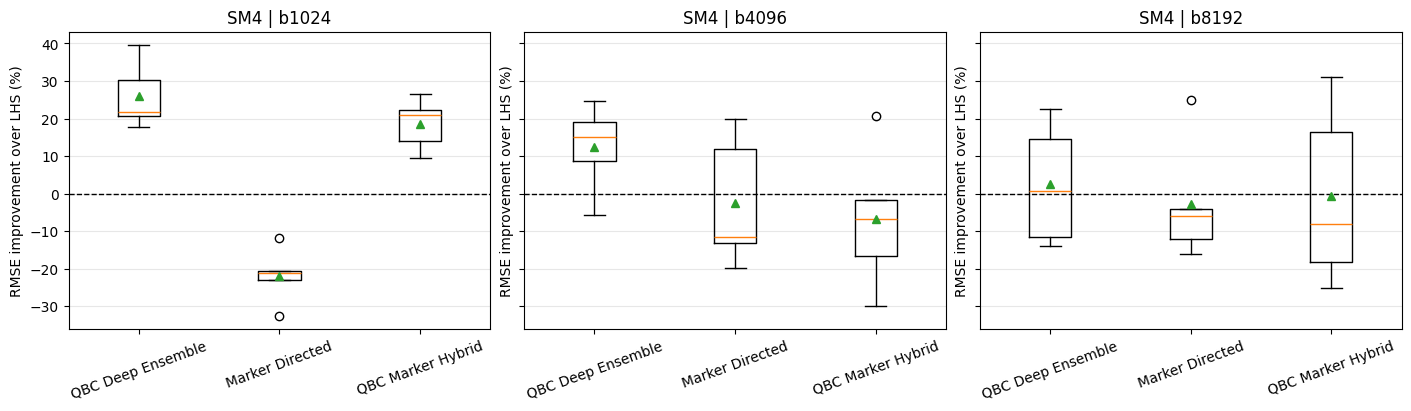

/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_10718/1536860088.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] for m in method_order], showmeans=True)
/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_10718/1536860088.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] for m in method_order], showmeans=True)
/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_10718/1536860088.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] fo

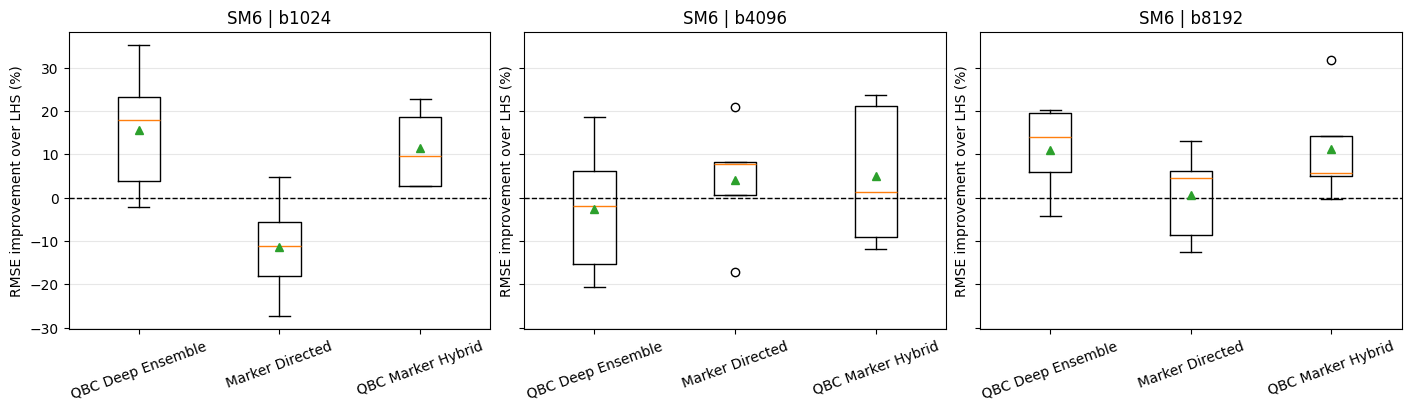

/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_10718/1536860088.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] for m in method_order], showmeans=True)
/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_10718/1536860088.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] for m in method_order], showmeans=True)
/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_10718/1536860088.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] fo

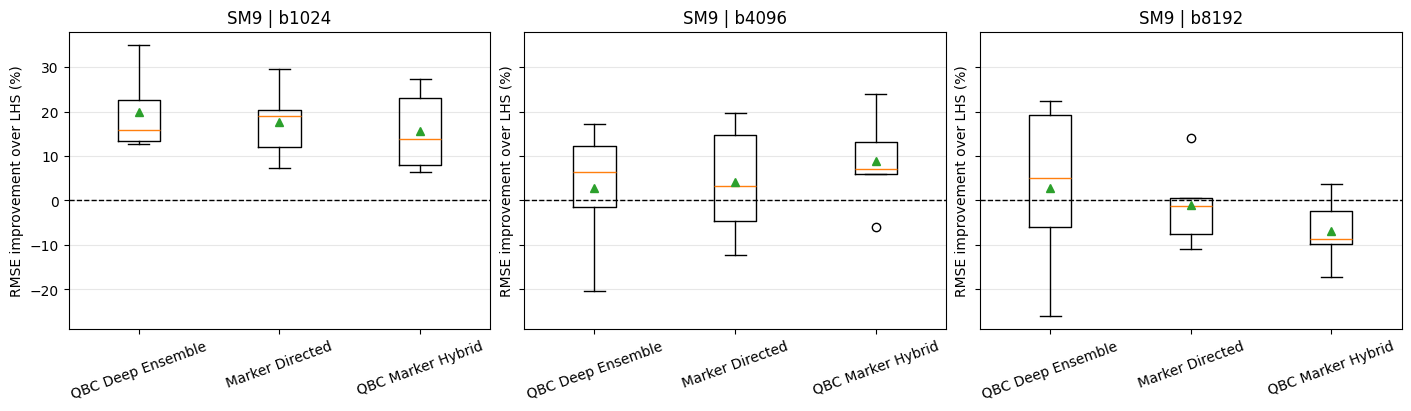

In [12]:
for campaign_label in [c for c in CAMPAIGN_LABELS.values() if c in paired_df['campaign_label'].unique()]:
    fig, axes = plt.subplots(1, len(budgets_present), figsize=(14, 4), constrained_layout=True, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, budget in zip(axes, budgets_present):
        sub = paired_df[(paired_df['campaign_label'] == campaign_label) & (paired_df['budget'].astype(str) == budget)].copy()
        method_order = [m for m in ADAPTIVE_METHODS if m in sub['method'].astype(str).unique()]
        grouped_values = [
            sub.loc[sub['method'].astype(str) == method, 'rmse_improvement_pct'].to_numpy()
            for method in method_order
        ]
        ax.boxplot(grouped_values, labels=[METHOD_LABELS[m] for m in method_order], showmeans=True)
        ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'{campaign_label} | {budget}')
        ax.set_ylabel('RMSE improvement over LHS (%)')
        ax.tick_params(axis='x', rotation=20)
        ax.grid(axis='y', alpha=0.3)
    plt.show()
